# Data Acquisition
**Goals:**
1. Pull OpenStreetMap network (GraphML file format)
2. Pull grocery stores (GeoDataframe -> GeoJSON)
3. (A) Pull Census tracts, boundaries (GeoJSON)
3. (B) Pull Census demographics (JSON -> Dataframe)
4. Pull transit stops (CSV)
5. Make visualizations
6. Save all outputs to `data/raw/` and `data/processed/`

In [47]:
import osmnx as ox
import geopandas as gpd
import pandas as pd
import folium
import os

CITY = "Kingstowne"
STATE = "Virginia"
STATE_FIPS = "51"
COUNTY_FIPS = "059"

PLACE = f"{CITY}, {STATE}"
RAW_DIR = "../data/raw"
PROCESSED_DIR = "../data/processed"
print(f"Working on {PLACE}...")

Working on Kingstowne, Virginia...


## 1. Network graph data
https://osmnx.readthedocs.io/en/stable/user-reference.html#osmnx.graph.graph_from_place

In [20]:
walk_graph = ox.graph_from_place(PLACE, network_type="walk")
print(f"Nodes: {len(walk_graph.nodes)}")
print(f"Edges: {len(walk_graph.edges)}")
ox.save_graphml(walk_graph, f"{RAW_DIR}/{CITY.lower()}_walk_network.graphml")

Nodes: 2653
Edges: 7400


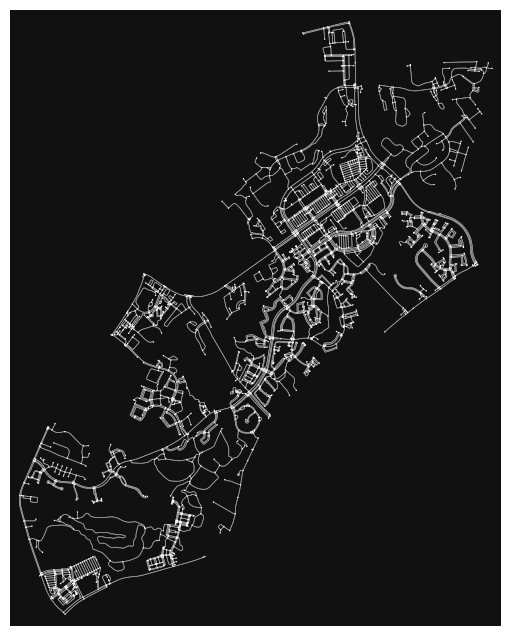

In [21]:
fig, ax = ox.plot_graph(
    walk_graph, 
    node_size=1, 
    edge_linewidth=0.5, 
)

## 2. Points of interest
https://osmnx.readthedocs.io/en/stable/user-reference.html#osmnx.features.features_from_place

In [22]:
poi_tags = {
    "grocery" : {"shop" : ["supermarket", "grocery"]}
}

pois = {}
for category, tags in poi_tags.items():
    try:
        gdf = ox.features_from_place(PLACE, tags)
        gdf = gdf[gdf.geometry.notnull()].copy()
        gdf["category"] = category
        pois[category] = gdf
        print(f"{category}: {len(gdf)} features")
    except Exception as e:
        print(f"{category} failed")

grocery: 4 features


In [23]:
gdf["geometry"] = gdf.geometry.apply(lambda geom: geom.centroid if geom.geom_type != "Point" else geom)
gdf = gdf[["geometry", "brand", "category"]]
gdf = gpd.GeoDataFrame(gdf, geometry="geometry", crs=pois[list(pois.keys())[0]].crs)
gdf.to_file(f"{RAW_DIR}/{CITY.lower()}_pois.geojson", driver="GeoJSON")
gdf

geometry    brand category
element id                                                      
node    4208133624  POINT (-77.13706 38.77271)    Giant  grocery
        7956135900  POINT (-77.13994 38.76798)     Aldi  grocery
        7956150256   POINT (-77.1414 38.77002)  Safeway  grocery
way     391755853   POINT (-77.16108 38.74257)  Wegmans  grocery

## 3A. Census tracts, boundaries, demographics
- Using 2024 boundary shapefile to match the most recent American Community Survey (2020-2024)
- https://www.census.gov/data/developers/updates/new-discovery-tool.html

In [26]:
tracts = gpd.read_file("../data/raw/tl_2024_51_tract/tl_2024_51_tract.shp")
print(f"Tracts pulled: {len(tracts)}")



Tracts pulled: 2198


In [ ]:
import requests

CENSUS_API_KEY = os.environ.get("CENSUS_API_KEY")

ACS_VARS = {
    "B19013_001E": "median_income",
    "B08201_002E": "no_vehicle_households",
    "B01003_001E": "population",
}

variables = ",".join(ACS_VARS.keys())
url = (
    f"https://api.census.gov/data/2024/acs/acs5"
    f"?get=NAME,{variables}&for=tract:*&in=state:{STATE_FIPS}&in=county:{COUNTY_FIPS}"
    f"&key={CENSUS_API_KEY}"
)
response = requests.get(url)
data = response.json()
acs_df = pd.DataFrame(data[1:], columns=data[0])
for col in ACS_VARS.keys():
    acs_df[col] = pd.to_numeric(acs_df[col], errors="coerce")
acs_df = acs_df.rename(columns=ACS_VARS)
acs_df["GEOID"] = acs_df["state"] + acs_df["county"] + acs_df["tract"]
print(f"Tract rows: {len(acs_df)}")


Tract rows: 274


In [53]:
acs_df[acs_df["population"] > 0].head()

,NAME,median_income,no_vehicle_households,population,state,county,tract,GEOID
0,Census Tract 4151; Fairfax County; Virginia,205938,16,3604,51,059,415100,51059415100
1,Census Tract 4152; Fairfax County; Virginia,107634,167,2966,51,059,415200,51059415200
2,Census Tract 4153; Fairfax County; Virginia,121795,313,4145,51,059,415300,51059415300
3,Census Tract 4154.01; Fairfax County; Virginia,85114,269,6688,51,059,415401,51059415401
4,Census Tract 4154.02; Fairfax County; Virginia,185481,15,2438,51,059,415402,51059415402


## 3B. Filter tracts to the study area and merge with demographics

In [54]:
city_boundary = ox.geocode_to_gdf(PLACE)
city_boundary = city_boundary.to_crs(tracts.crs)

tracts_in_city = gpd.sjoin(tracts, city_boundary, predicate="intersects", how="inner")
tracts_in_city = tracts_in_city.drop(columns=[c for c in tracts_in_city.columns if c.endswith("_right")])
print(f"Tracts intersecting {CITY}: {len(tracts_in_city)}")

Tracts intersecting Kingstowne: 10


In [55]:
tracts_merged = tracts_in_city.merge(acs_df, on="GEOID", how="left")
print(f"Merged tracts: {len(tracts_merged)}, missing demographic data: {tracts_merged['median_income'].isna().sum()}")
tracts_merged[["GEOID", "median_income", "no_vehicle_households", "population"]].head()

Merged tracts: 10, missing demographic data: 0


,GEOID,median_income,no_vehicle_households,population
0,51059421103,145865,29,6355
1,51059422401,129054,28,2800
2,51059422403,236012,0,3186
3,51059422402,151451,54,4984
4,51059421101,183891,12,5872


In [56]:
tracts_merged.to_file(f"{PROCESSED_DIR}/{CITY.lower()}_tracts_demographics.geojson", driver="GeoJSON")

## 4. Transit data

## 5. Visualizations

In [ ]:
center = city_boundary.geometry.iloc[0].centroid
m = folium.Map(location=[center.y, center.x], zoom_start=12, tiles="cartodbpositron")

folium.GeoJson(
    tracts_merged.to_crs(4326),
    style_function=lambda x: {"fillColor": "#ffffff00", "color": "#666666", "weight": 1},
).add_to(m)

pois_wgs84 = gdf.to_crs(4326)
colors = {"grocery": "green"}
for _, row in pois_wgs84.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=3,
        color=colors.get(row["category"], "gray"),
        fill=True,
        popup=row.get("name", row["category"]),
    ).add_to(m)

m
